# Data Loading

In [1]:
import matplotlib.pyplot as plt
import os
import zipfile
try:
    import gdown
except ImportError:
    !pip install gdown

def download_dataset_from_google_drive(google_file_id: str, output_file_name: str, quiet_download: bool) -> str:
    file_path = f'./{output_file_name}'

    if not os.path.exists(file_path):
        gdown.download(id=google_file_id, output=output_file_name, quiet=quiet_download)
    else:
        print(f"{output_file_name} already exists!")
    if os.path.exists(file_path):
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall('./')
    return file_path

In [2]:
#https://drive.google.com/file/d/1ke6APNDoRqSCSoaHbncT_WpmSNCT9sbh/view?usp=sharing
data_path = "1ke6APNDoRqSCSoaHbncT_WpmSNCT9sbh"

In [3]:
data_dir = download_dataset_from_google_drive(data_path, "data.zip", True)

In [4]:
import os
import numpy as np
import random

def read_text_files(folder_path):
    """Reads all text files in the given folder."""
    contents = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        # Check if it's a file and has .txt extension
        if os.path.isfile(file_path) and filename.endswith(".txt"):
            with open(file_path, "r") as file:
                content = file.read()
                contents.append(content)
    return contents

In [5]:
# Training set
train_positive_reviews = read_text_files("aclImdb/train/pos/")
train_negative_reviews = read_text_files("aclImdb/train/neg/")
train_reviews = train_positive_reviews + train_negative_reviews
y_train = np.array([1]*12500 + [0]*12500)#.astype('int32')
#Test set
test_positive_reviews = read_text_files("aclImdb/test/pos/")
test_negative_reviews = read_text_files("aclImdb/test/neg/")
test_reviews = test_positive_reviews + test_negative_reviews
y_test = np.array([1]*12500 + [0]*12500)#.astype('int32')


# Data Processing

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [7]:
vocabulary = 10000
tokenizer = Tokenizer(num_words = vocabulary)

In [8]:
tokenizer.fit_on_texts(train_reviews)

In [9]:
word_index = tokenizer.word_index

In [10]:
sequences_train = tokenizer.texts_to_sequences(train_reviews)

In [11]:
word_num = 20
x_train = pad_sequences(sequences_train, maxlen = word_num)

## Split Training and Validation Data and Process Test Data

In [12]:
n = x_train.shape[0]
rand_perm = np.random.permutation(n)
n_valid = int(n * 0.2)
labels_train = np.array(y_train)
x_valid = x_train[rand_perm[0:n_valid], :]
y_valid = labels_train[rand_perm[0:n_valid]]
x_train = x_train[rand_perm[n_valid:n], :]
y_train = labels_train[rand_perm[n_valid:n]]

In [13]:
word_index = tokenizer.word_index
sequences_test = tokenizer.texts_to_sequences(test_reviews)
word_num = 20
x_test = pad_sequences(sequences_test, maxlen=word_num)

In [14]:
from keras.models import Sequential
from keras.layers import Flatten, Dense, Embedding, Input

In [15]:
embedding_dim = 8
model = Sequential()
model.add(Input((word_num, )))
model.add(Embedding(vocabulary, embedding_dim))
model.add(Flatten())
model.add(Dense(1, activation="sigmoid"))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 8)               │          80,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 160)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 80,161 (313.13 KB)

 Trainable params: 80,161 (313.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from keras import optimizers

epochs = 50

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0001),
              loss = "binary_crossentropy", metrics = ['acc'])

In [17]:
history = model.fit(x_train, y_train, epochs=epochs, batch_size=32, validation_data=(x_valid, y_valid))

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.5089 - loss: 0.6928 - val_acc: 0.5174 - val_loss: 0.6923
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.5458 - loss: 0.6909 - val_acc: 0.5440 - val_loss: 0.6907
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.5847 - loss: 0.6882 - val_acc: 0.5636 - val_loss: 0.6883
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6248 - loss: 0.6844 - val_acc: 0.5964 - val_loss: 0.6845
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6604 - loss: 0.6788 - val_acc: 0.6284 - val_loss: 0.6789
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6907 - loss: 0.6718 - val_acc: 0.6500 - val_loss: 0.6714
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.7050 - loss: 0.6625 - val_acc: 0.6664 - val_loss: 0.6618
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.7240 - loss: 0.6504 - val_acc: 0.6782 - val_loss: 0.6504
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

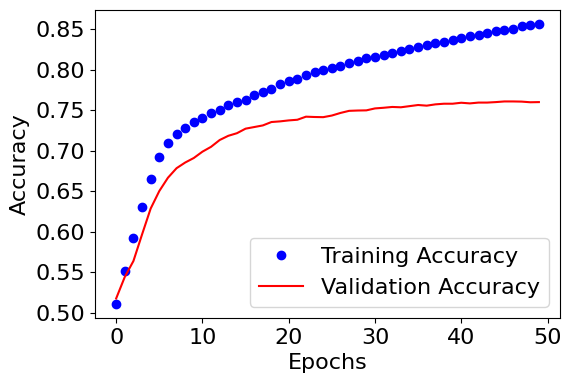

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(6, 4))
epochs_list = range(epochs)
train_acc = history.history['acc']
valid_acc = history.history['val_acc']
plt.plot(epochs_list, train_acc, 'bo', label='Training Accuracy')
plt.plot(epochs_list, valid_acc, 'r', label='Validation Accuracy')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

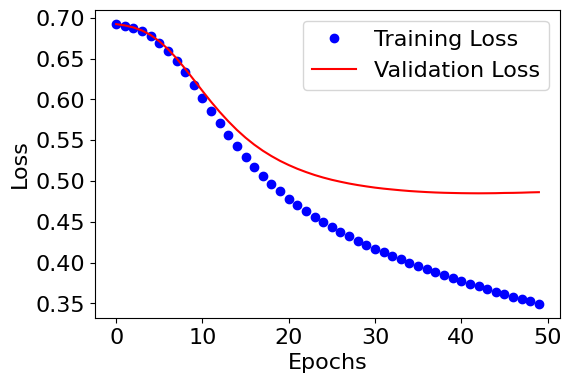

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(6, 4))
epochs_list = range(epochs)
train_loss = history.history['loss']
valid_loss = history.history['val_loss']
plt.plot(epochs_list, train_loss, 'bo', label='Training Loss')
plt.plot(epochs_list, valid_loss, 'r', label='Validation Loss')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

In [20]:
loss_and_acc = model.evaluate(x_test, y_test)
print('loss = ' + str(loss_and_acc[0]))
print('acc = ' + str(loss_and_acc[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.7701 - loss: 0.4837
loss = 0.4850451648235321
acc = 0.7633600234985352
